In [18]:
# Step 1 — Data Collection & Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
# Load the Netflix dataset
df = pd.read_csv('netflix_titles 3.csv')
# Basic info
print(df.shape)
# (8807, 12)
print(df.dtypes)
# column types
print(df.head())
# first 5 rows
print(df.isnull().sum())
# missing values per column
# Dataset columns:
# show_id, type, title, director, cast, country,
# date_added, release_year, rating, duration,
# listed_in (genres), description
df.describe(include='all')

(8807, 12)
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                         

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [19]:
# Step 2 — Data Cleaning & Preprocessing
# Filter only Movies (drop TV Shows for the recommender)
movies = df[df['type'] == 'Movie'].copy()
print(f"Movies: {len(movies)}")
# 6131
# Drop exact duplicates
movies = movies.drop_duplicates(subset='title')
# Fill missing values
movies['director'] = movies['director'].fillna('')
movies['cast'] = movies['cast'].fillna('')
movies['country'] = movies['country'].fillna('Unknown')
movies['rating'] = movies['rating'].fillna('NR')
movies['description'] = movies['description'].fillna('')
movies['listed_in'] = movies['listed_in'].fillna('')
# Clean genres — replace commas with spaces for TF-IDF
movies['genres_clean'] = movies['listed_in'].str.replace(',', ' ')
# Encode genres as binary columns (multi-hot encoding)
genres_dummies = movies['listed_in'].str.get_dummies(sep=', ')
movies = pd.concat([movies, genres_dummies], axis=1)
# Convert release_year to int
movies['release_year'] = pd.to_numeric(movies['release_year'], errors='coerce')
# Reset index
movies = movies.reset_index(drop=True)
print(movies.shape)

Movies: 6131
(6131, 33)


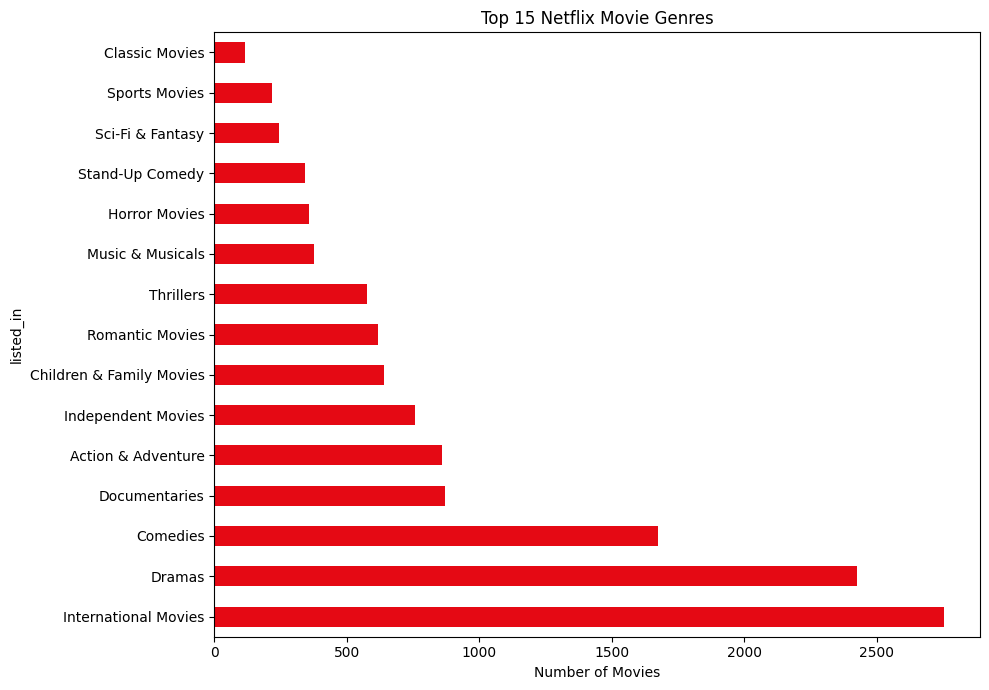

In [20]:
# Step 3 — Exploratory Data Analysis (EDA)
# ── Genre Distribution ──────────────────────────────────
genre_counts = movies['listed_in'].str.split(', ').explode().value_counts()
genre_counts[:15].plot(kind='barh', figsize=(10, 7), color='#E50914')
plt.title('Top 15 Netflix Movie Genres')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.show()


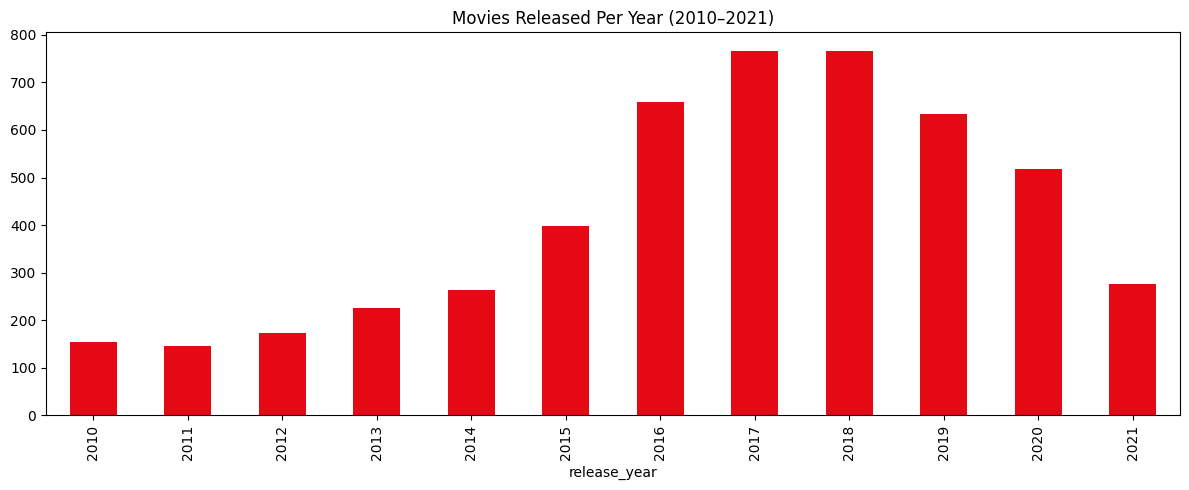

In [21]:
# ── Content Growth Over Time ─────────────────────────────
year_counts = movies['release_year'].value_counts().sort_index()
year_counts[year_counts.index >= 2010].plot(kind='bar', figsize=(12, 5), color='#E50914')
plt.title('Movies Released Per Year (2010–2021)')
plt.tight_layout()
plt.show()

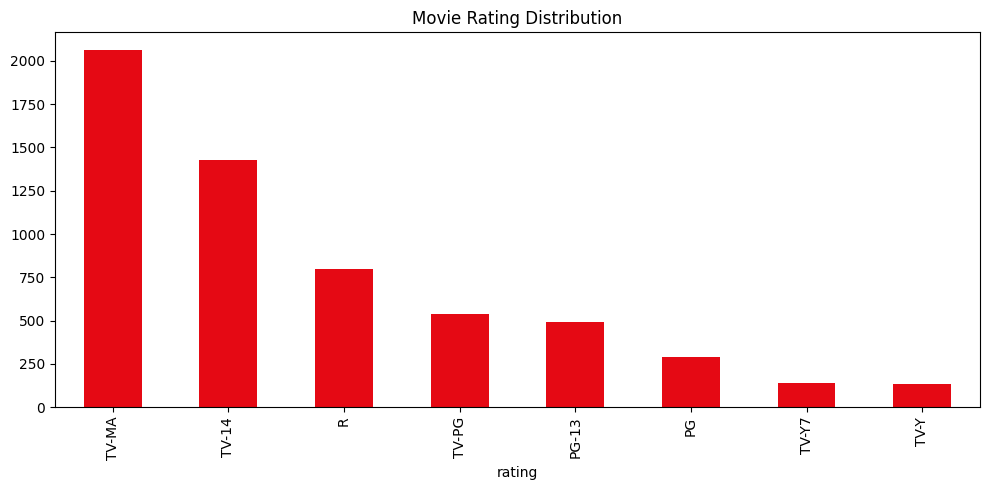

In [22]:
# ── Rating Distribution ──────────────────────────────────
rating_counts = movies['rating'].value_counts()[:8]
rating_counts.plot(kind='bar', figsize=(10, 5), color='#E50914')
plt.title('Movie Rating Distribution')
plt.tight_layout()
plt.show()

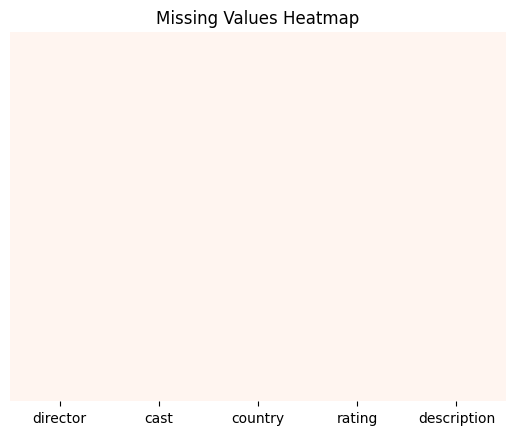

In [23]:
# ── Missing Values Heatmap ───────────────────────────────
sns.heatmap(movies[['director','cast','country','rating','description']].isnull(), yticklabels=False, cbar=False, cmap='Reds')
plt.title('Missing Values Heatmap')
plt.show()

In [24]:
# Step 4 — TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

# Combine text features into one "soup"
# Genre is repeated to give it more importance
def create_soup(row):
    genres = str(row['listed_in']).replace(',', ' ').lower()
    description = str(row['description']).lower()
    director = str(row['director']).lower().replace(' ', '_')

    return f"{genres} {genres} {description} {director}"

# Apply function to create new column
movies['soup'] = movies.apply(create_soup, axis=1)

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',      # remove common words
    ngram_range=(1, 2),        # include unigrams and bigrams
    max_features=5000,         # limit to top 5000 features
    min_df=2                   # ignore very rare words
)

# Fit and transform the text data
tfidf_matrix = tfidf.fit_transform(movies['soup'])

# Shape of the resulting matrix
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

# Inspect feature names
feature_names = tfidf.get_feature_names_out()
print("Sample TF-IDF features:", feature_names[:20])

TF-IDF Matrix Shape: (6131, 5000)
Sample TF-IDF features: ['000' '007' '10' '10 year' '100' '11' '11 year' '12' '12 year' '13' '14'
 '14 year' '15' '15 year' '1590' '1590 wandering' '16' '16 year' '17'
 '17 year']


In [25]:
# Step 5 — Cosine Similarity Matrix

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Compute n × n similarity matrix
# cosine_similarity measures similarity between TF-IDF vectors
# 1.0 = identical, 0.0 = completely different
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine Similarity Matrix Shape:", cosine_sim.shape)
# Example: (6131, 6131)

# Create reverse mapping: movie title → index
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

# Example: get recommendations for a movie
movie_title = "Jaws"

# Get index of the movie
idx = indices[movie_title]

# Get similarity scores (movie with all other movies)
sim_scores = list(enumerate(cosine_sim[idx]))

# Sort movies based on similarity score
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

# Get top 5 similar movies (excluding itself)
top_5 = sim_scores[1:6]

print("Top 5 similar movies (index, score):")
print(top_5)

Cosine Similarity Matrix Shape: (6131, 6131)
Top 5 similar movies (index, score):
[(1549, np.float64(0.5153699788835907)), (5106, np.float64(0.4978240261158922)), (5576, np.float64(0.4872780474591325)), (4196, np.float64(0.4689806522750605)), (5283, np.float64(0.4652312325540144))]


In [26]:
# Step 6 — Recommendation Function

import pandas as pd

def get_recommendations(title, cosine_sim=cosine_sim, n=10, min_year=None, rating_filter=None):
    """
    Get top-N movie recommendations based on cosine similarity.

    Args:
        title : Movie title (must exist in dataset)
        cosine_sim : Pre-computed similarity matrix
        n : Number of recommendations to return
        min_year : Optional minimum release year filter
        rating_filter: Optional rating string filter (e.g. 'PG-13')

    Returns:
        DataFrame with recommended movies and similarity scores
    """

    # Check if movie exists
    if title not in indices:
        return f"Movie '{title}' not found in dataset."

    # Get index of the movie
    idx = indices[title]

    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort based on similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Remove self-match
    sim_scores = sim_scores[1:]

    # Apply filters and collect results
    results = []

    for i, score in sim_scores:
        movie = movies.iloc[i]

        # Apply optional filters
        if min_year and movie['release_year'] < min_year:
            continue
        if rating_filter and movie['rating'] != rating_filter:
            continue

        results.append({
            'title': movie['title'],
            'year': movie['release_year'],
            'rating': movie['rating'],
            'genres': movie['listed_in'],
            'similarity': round(score * 100, 1),
            'description': movie['description']
        })

        if len(results) >= n:
            break

    return pd.DataFrame(results)


# Example usage
recs = get_recommendations('Jaws', n=5)

print(recs[['title', 'year', 'similarity']])

                  title  year  similarity
0               Saladin  1963        51.5
1  Mutiny on the Bounty  1962        49.8
2              Superfly  1972        48.7
3      Bonnie and Clyde  1967        46.9
4               Platoon  1986        46.5
